## Navier-Stokes fluid with a rectangular obstacle (2D)

### Imports 

In [1]:
import deepxde as dde
import numpy as np
import tensorflow as tf 
import matplotlib.pyplot as plt

Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
# Set default float type to float32 for better performance

dde.config.set_default_float("float32")

Set the default float type to float32


### Geometry and PDE definition

In [3]:
R = 0.05 # radius of the cylinder

geom_rect = dde.geometry.Rectangle(xmin=[-0.2, -0.2], xmax=[0.8, 0.2]) # 1m long and 0.4m wide
geom_obs = dde.geometry.Rectangle(xmin=[0, -0.05], xmax=[0.4, 0.05]) # obstacle centered at the origin with dimensions 0.4m x 0.1m
geom = dde.geometry.CSGDifference(geom_rect, geom_obs)

In [ ]:
def pde(x, y):
    u = y[:, 0:1]
    v = y[:, 1:2]

    nu = 0.01

    u_x = dde.grad.jacobian(y, x, i=0, j=0)
    u_y = dde.grad.jacobian(y, x, i=0, j=1)
    v_x = dde.grad.jacobian(y, x, i=1, j=0)
    v_y = dde.grad.jacobian(y, x, i=1, j=1)
    p_x = dde.grad.jacobian(y, x, i=2, j=0)
    p_y = dde.grad.jacobian(y, x, i=2, j=1)

    u_xx = dde.grad.hessian(y, x, component=0, i=0, j=0)
    u_yy = dde.grad.hessian(y, x, component=0, i=1, j=1)
    v_xx = dde.grad.hessian(y, x, component=1, i=0, j=0)
    v_yy = dde.grad.hessian(y, x, component=1, i=1, j=1)

    continuity = u_x + v_y
    momentum_x = u * u_x + v * u_y + p_x - nu * (u_xx + u_yy)
    momentum_y = u * v_x + v * v_y + p_y - nu * (v_xx + v_yy)

    return [continuity, momentum_x, momentum_y]

### Boundaries definitions

In [5]:
u_max = 1.0 # maximum velocity at the center of the inlet
h_max = 0.2 # distance from center to wall

def u_inlet(x): # parabolic velocity profile at the inlet
    y = x[:, 1:2]
    return u_max * (1 - (y / h_max) ** 2)

def inlet(x, on_boundary): # function to identify the inlet boundary
    return on_boundary and np.isclose(x[0], -0.2)

bc_in_u = dde.DirichletBC(geom, u_inlet, inlet, component=0)
bc_in_v = dde.DirichletBC(geom, lambda x: 0, inlet, component=1)

def outlet(x, on_boundary): # function to identify the outlet boundary
    return on_boundary and np.isclose(x[0], 0.8)

bc_out_p = dde.DirichletBC(geom, lambda x: 0, outlet, component=2)

def walls(x, on_boundary): # function to identify the top and bottom walls
    return on_boundary and (np.isclose(x[1], -0.2) or np.isclose(x[1], 0.2))

bc_wall_u = dde.DirichletBC(geom, lambda x: 0, walls, component=0)
bc_wall_v = dde.DirichletBC(geom, lambda x: 0, walls, component=1)

def rectangle(x, on_boundary): # function to identify the rectangle boundary
    return on_boundary and (np.isclose(x[0], 0) or np.isclose(x[0], 0.4) or np.isclose(x[1], -0.05) or np.isclose(x[1], 0.05))

bc_rect_u = dde.DirichletBC(geom, lambda x: 0, rectangle, component=0)
bc_rect_v = dde.DirichletBC(geom, lambda x: 0, rectangle, component=1)

### Data points

In [6]:
x_left = np.random.uniform(-0.05, 0.0, 500)
y_left = np.random.uniform(-0.1, 0.1, 500)
pts_left = np.vstack((x_left, y_left)).T

x_right = np.random.uniform(0.4, 0.45, 500)
y_right = np.random.uniform(-0.1, 0.1, 500)
pts_right = np.vstack((x_right, y_right)).T

x_top = np.random.uniform(0.0, 0.4, 1000)
y_top = np.random.uniform(0.05, 0.1, 1000)
pts_top = np.vstack((x_top, y_top)).T

x_bottom = np.random.uniform(0.0, 0.4, 1000)
y_bottom = np.random.uniform(-0.1, -0.05, 1000)
pts_bottom = np.vstack((x_bottom, y_bottom)).T

rectangle_points = np.vstack((pts_left, pts_right, pts_top, pts_bottom))

In [7]:
data = dde.data.PDE(
    geom,
    pde,
    [bc_in_u, bc_in_v, bc_out_p, bc_wall_u, bc_wall_v, bc_rect_u, bc_rect_v],
    num_domain=4000,
    num_boundary=1500,
    anchors=rectangle_points
)

### Model definition and training

In [8]:
net = dde.nn.FNN([2] + [64]*5 + [3], "tanh", "Glorot uniform")
model = dde.Model(data, net)

In [9]:
weights = [1.0, 1.0, 1.0,  5.0, 5.0,  1.0,  5.0, 5.0,  20.0, 20.0] # PDE, inlet BC, outlet BC, wall BC, cylinder BC

model.compile("adam", lr=1e-3, loss_weights=weights)

model.compile("adam", lr=5e-4, loss_weights=weights)

model.predict(np.zeros((1, 2))) 

model.net.load_weights("pinn_rectangle_model-25000.weights.h5")


Compiling model...
'compile' took 0.060715 s

Compiling model...
'compile' took 0.003053 s



In [ ]:
#model.save("pinn_rectangle_model") 

'pinn_rectangle_model-25000.weights.h5'

### Plotting

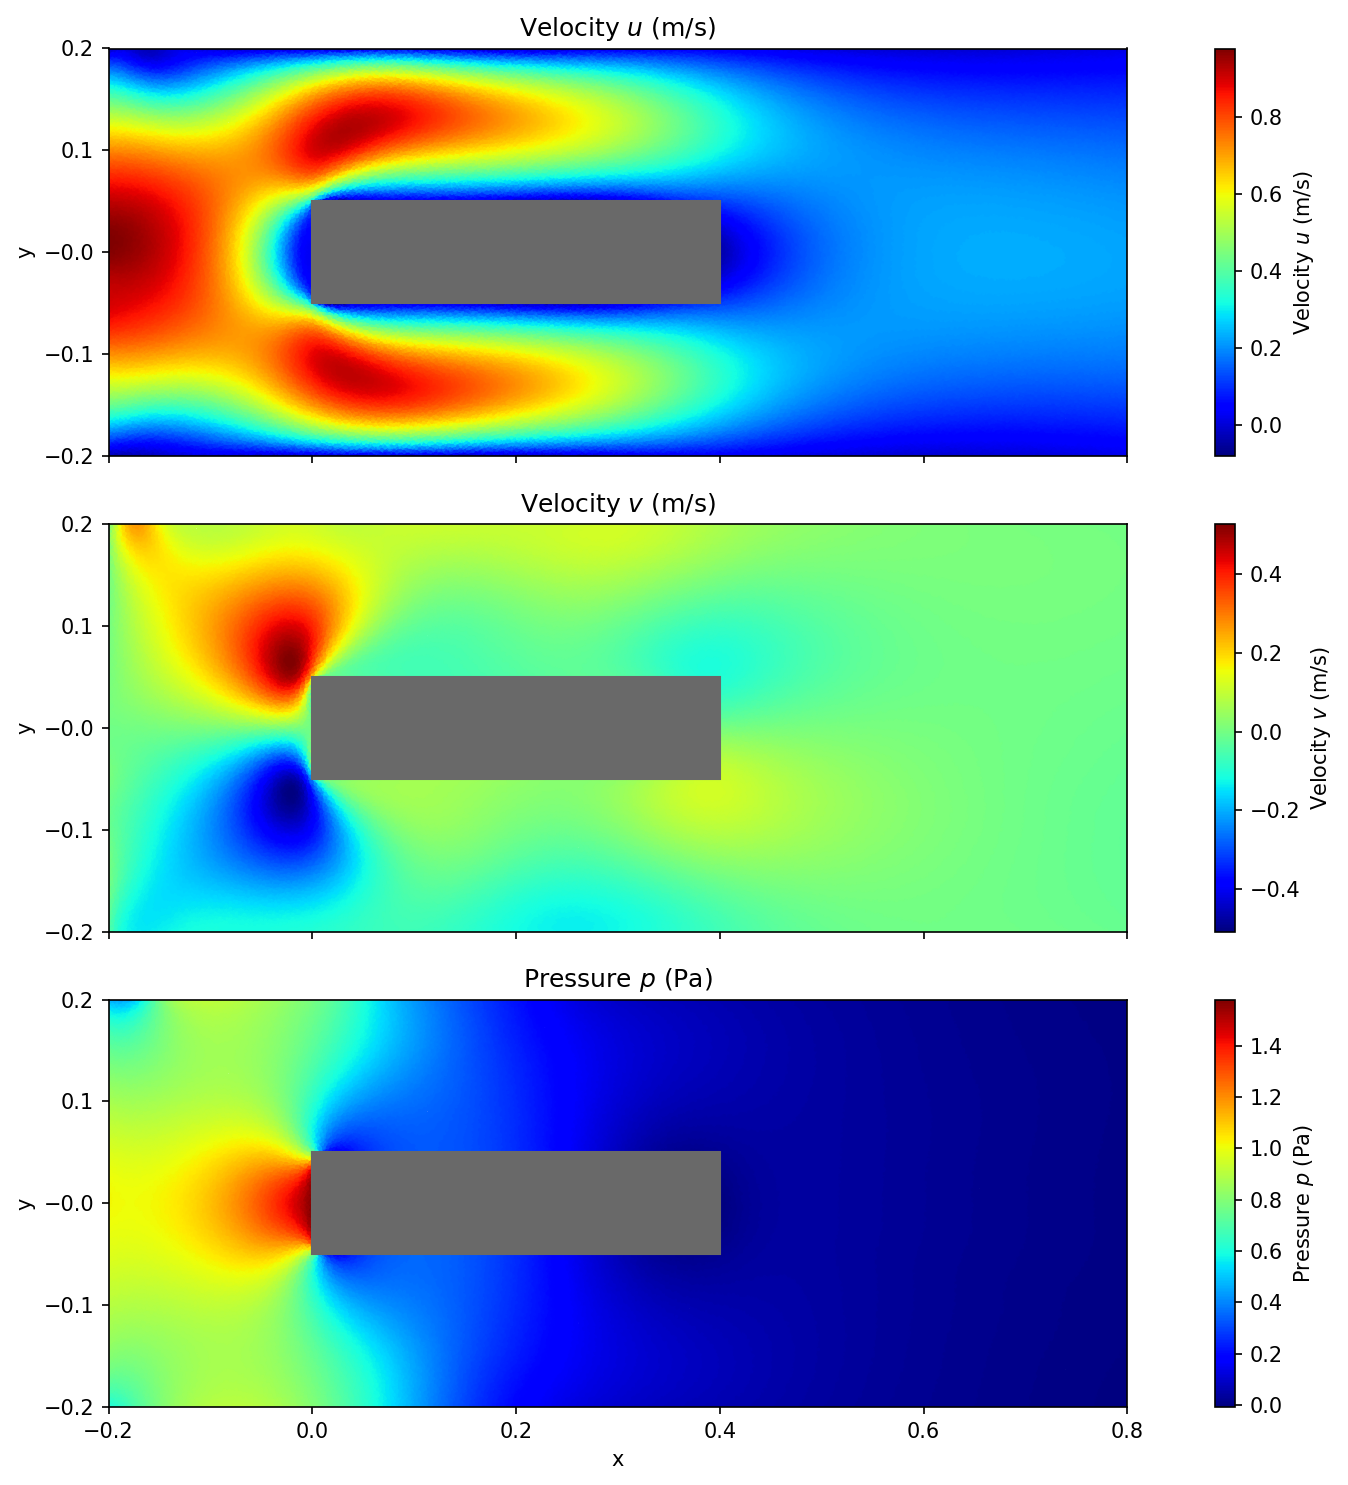

In [ ]:
from matplotlib.patches import Rectangle

samples = geom.random_points(500000)
result = model.predict(samples)

magnituds = [f"Velocity $u$ (m/s)", f"Velocity $v$ (m/s)", f"Pressure $p$ (Pa)"]

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 10), sharex=True, dpi=150)

xmin, xmax = samples[:, 0].min(), samples[:, 0].max()
ymin, ymax = samples[:, 1].min(), samples[:, 1].max()

for idx, ax in enumerate(axes):
    sc = ax.scatter(samples[:, 0], samples[:, 1], c=result[:, idx], cmap="jet", s=0.5)
    
    obstacle = Rectangle((0.0, -0.05), 0.4, 0.1, color='dimgray', zorder=10)
    ax.add_patch(obstacle)

    ax.set_aspect('equal')
    
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    
    ax.set_xticks(np.linspace(xmin, xmax, 6))
    ax.set_yticks(np.linspace(ymin, ymax, 5))
    
    ax.set_title(f"{magnituds[idx]}")
    ax.set_ylabel("y")
    
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(magnituds[idx])

axes[-1].set_xlabel("x")

plt.tight_layout()    
plt.show()